In [1]:
# import warnings
# from numba.core.errors import NumbaWarning, NumbaPerformanceWarning

# warnings.filterwarnings("ignore", category=NumbaWarning)
# warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)

from ler import LeR
# [16, 16, 30, 11, 11]
spacing_config = {
    # "e1": {
    #     "mode": "powerlaw_mixed", 
    #     "power_law_part": "upper",
    #     "spacing_trend": "decreasing",
    #     "power": 2.5,
    #     "value_transition_fraction": 0.4,
    #     "num_transition_fraction": 0.2,
    #     "auto_match_slope": True
    # },
    # "e2": {
    #     "mode": "powerlaw_mixed", 
    #     "power_law_part": "upper",
    #     "spacing_trend": "decreasing",
    #     "power": 2.5,
    #     "value_transition_fraction": 0.4,
    #     "num_transition_fraction": 0.2,
    #     "auto_match_slope": True
    # },
    "e1": {
        "mode": "two_sided_mixed_grid", 
        "power_law_part": "lower",
        "spacing_trend": "increasing",
        "power": 2.5,
        "value_transition_fraction": 0.7,
        "num_transition_fraction": 0.9,
        "auto_match_slope": True
    },
    "e2": {
        "mode": "two_sided_mixed_grid", 
        "power_law_part": "lower",
        "spacing_trend": "increasing",
        "power": 2.5,
        "value_transition_fraction": 0.7,
        "num_transition_fraction": 0.9,
        "auto_match_slope": True
    },
    # "e1": {"mode": "linear"},
    # "e2": {"mode": "linear"},
    # "gamma": {"mode": "linear"},
    # "gamma": {
    #     "mode": "powerlaw_mixed", 
    #     "power_law_part": "lower",
    #     "spacing_trend": "increasing",
    #     "power": 2.5,
    #     "value_transition_fraction": 0.6,
    #     "num_transition_fraction": 0.8,
    #     "auto_match_slope": True
    # },
    "gamma": {
        "mode": "two_sided_mixed_grid", 
        "power_law_part": "lower",
        "spacing_trend": "increasing",
        "power": 2.5,
        "value_transition_fraction": 0.7,
        "num_transition_fraction": 0.9,
        "auto_match_slope": True
    },
    # "gamma1": {"mode": "linear"},
    # "gamma2": {"mode": "linear"},
    "gamma1": {
        "mode": "two_sided_mixed_grid", 
        "power_law_part": "lower",
        "spacing_trend": "increasing",
        "power": 2.5,
        "value_transition_fraction": 0.7,
        "num_transition_fraction": 0.9,
        "auto_match_slope": True
    },
    "gamma2": {
        "mode": "two_sided_mixed_grid", 
        "power_law_part": "lower",
        "spacing_trend": "increasing",
        "power": 2.5,
        "value_transition_fraction": 0.7,
        "num_transition_fraction": 0.9,
        "auto_match_slope": True
    },
}

bool_ = False
ler = LeR(
    npool=6,
    create_new_interpolator = dict(
        cross_section=dict(
            create_new=True, 
            resolution=[25, 25, 45, 15, 15], #[16, 16, 30, 11, 11], [25, 25, 45, 15, 15]
            spacing_config=spacing_config),
        # lens_redshift=dict(create_new=bool_, resolution=48, zl_resolution=48),
        # optical_depth=dict(create_new=bool_, resolution=48),
        # source_redshift_sl=dict(create_new=bool_, resolution=500),
    )
)
# mp: 4m 2.7s
# njit: 3m 45s


Initializing LeR class...


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ./interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ./interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ./interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ./interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : axis_ratio_rayleigh
axis_ratio_rayleigh interpolator will be loaded from ./interpolator_json/a

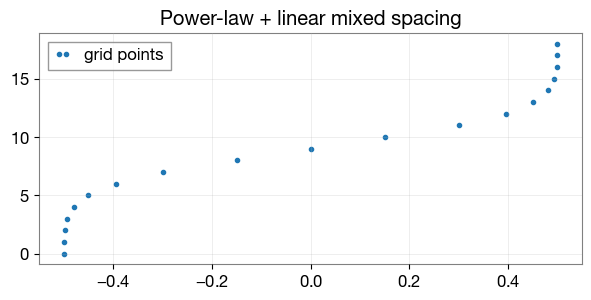

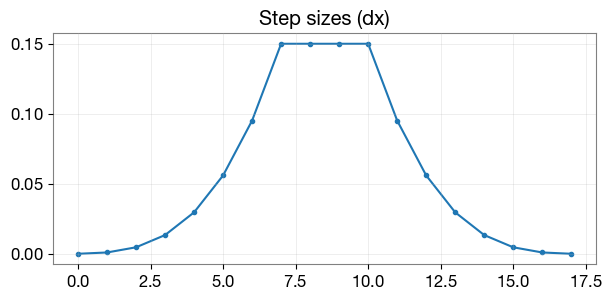

In [81]:
import numpy as np
import matplotlib.pyplot as plt

def generate_mixed_grid(
    x_min,
    x_max,
    resolution,
    power_law_part='lower',
    spacing_trend='increasing',
    power=2.3,
    value_transition_fraction=0.3,
    num_transition_fraction=0.6,
    auto_match_slope=True,
):
    """
    Generalized mixed spacing grid generator. Safely handles negative ranges.

    Parameters
    ----------
    x_min, x_max : float
        The physical domain boundaries (can be negative, crossing zero, etc.).
    power_law_part : str
        'lower' to apply power-law to the first segment.
        'upper' to apply power-law to the second segment.
    spacing_trend : str
        'increasing': Step sizes grow as x increases.
        'decreasing': Step sizes shrink as x increases.
    power : float
        Exponent (>= 1.0) to control curvature. Overridden if auto_match_slope=True.
    auto_match_slope : bool
        If True, analytically calculates the required power AND trend to guarantee 
        a smooth transition without a kink.
    """
    if x_max <= x_min:
        return np.linspace(x_min, x_max, resolution)

    # 1. Normalized transition parameter
    u_trans = float(np.clip(value_transition_fraction, 0.0, 1.0))
    
    if u_trans <= 0.0 or u_trans >= 1.0:
        return np.linspace(x_min, x_max, resolution)

    if num_transition_fraction is None:
        num_transition_fraction = u_trans

    n_low = max(2, int(resolution * num_transition_fraction))
    n_low = min(n_low, resolution - 1)
    n_high = resolution - n_low

    # 2. Build the grid in normalized [0, 1] space
    if power_law_part == 'lower':
        du_lin = (1.0 - u_trans) / n_high
        ratio = du_lin / u_trans
        N_int = n_low - 1

        if auto_match_slope and N_int > 1:
            if ratio >= 1.0:
                power, spacing_trend = 1.0, 'increasing'
            elif ratio > 1.0 / N_int:
                spacing_trend = 'increasing'
                power = np.log(1.0 - ratio) / np.log((N_int - 1) / N_int)
            else:
                spacing_trend = 'decreasing'
                power = np.log(ratio) / np.log(1.0 / N_int)

        t = np.linspace(0.0, 1.0, n_low)
        if spacing_trend == 'increasing':
            u_low = u_trans * (t ** power)
        else:
            u_low = u_trans * (1.0 - (1.0 - t) ** power)
        
        u_high = np.linspace(u_trans, 1.0, n_high + 1)[1:]
        u_grid = np.concatenate([u_low, u_high])

    elif power_law_part == 'upper':
        du_lin = u_trans / (n_low - 1)
        ratio = du_lin / (1.0 - u_trans)
        N_int = n_high

        if auto_match_slope and N_int > 1:
            if ratio >= 1.0:
                power, spacing_trend = 1.0, 'increasing'
            elif ratio < 1.0 / N_int:
                spacing_trend = 'increasing'
                power = np.log(ratio) / np.log(1.0 / N_int)
            else:
                spacing_trend = 'decreasing'
                power = np.log(1.0 - ratio) / np.log((N_int - 1) / N_int)

        t = np.linspace(0.0, 1.0, n_high + 1)[1:]
        if spacing_trend == 'increasing':
            u_high = u_trans + (1.0 - u_trans) * (t ** power)
        else:
            u_high = u_trans + (1.0 - u_trans) * (1.0 - (1.0 - t) ** power)

        u_low = np.linspace(0.0, u_trans, n_low)
        u_grid = np.concatenate([u_low, u_high])

    else:
        raise ValueError("power_law_part must be 'lower' or 'upper'")

    # 3. Map the normalized grid [0, 1] to the physical domain [x_min, x_max]
    return x_min + u_grid * (x_max - x_min)

# x = generate_mixed_grid(
#     z_min=0.0, z_max=10.0, resolution=20,
#     power_law_part='lower',
#     spacing_trend='decreasing',
#     value_transition_fraction=0.3,
#     num_transition_fraction=0.6,
#     auto_match_slope=True
# )

resolution=10
# x = generate_mixed_grid(
#     x_min=0.0, x_max=10.0, resolution=resolution,
#     power_law_part='upper',
#     spacing_trend='decreasing',  # Forces largest steps near z_trans
#     power=2.5,
#     value_transition_fraction=0.6,
#     num_transition_fraction=0.3,
#     auto_match_slope=True       # We accept the kink to control the exact power
# )

# x = generate_mixed_grid(
#     x_min=0.0, x_max=10.0, resolution=resolution,
#     power_law_part='lower',
#     spacing_trend='increasing',  # Forces largest steps near z_trans
#     power=2.5,
#     value_transition_fraction=0.7, # controls where the transition happens in terms of x values
#     num_transition_fraction=0.9, # controls how many points are in the first segment vs second segment
#     auto_match_slope=True       # We accept the kink to control the exact power
# )

# resolution=16
# x = generate_mixed_grid(
#     x_min=-0.8328873689023042, 
#     x_max=0.8328710261593968, 
#     resolution=resolution,
#     power_law_part='upper',
#     spacing_trend='decreasing',  # Forces largest steps near z_trans
#     power=2.5,
#     value_transition_fraction=0.4,
#     num_transition_fraction=0.2,
#     auto_match_slope=True       # We accept the kink to control the exact power
# )

x1 = generate_mixed_grid(
    x_min=0.0, x_max=0.5, resolution=resolution,
    power_law_part='lower',
    spacing_trend='increasing',  # Forces largest steps near z_trans
    power=2.5,
    value_transition_fraction=0.7, # controls where the transition happens in terms of x values
    num_transition_fraction=0.9, # controls how many points are in the first segment vs second segment
    auto_match_slope=True       # We accept the kink to control the exact power
)

x2 = np.sort(1-x1)[1:]
u_grid = np.concatenate([x1, x2])
x_min, x_max = -0.5, 0.5
x = x_min + u_grid * (x_max - x_min)
resolution = len(x)

plt.figure(figsize=(7, 3))
plt.plot(x, np.arange(resolution), '.', label='grid points')
plt.title('Power-law + linear mixed spacing')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# plt.figure(figsize=(7, 3))
# plt.plot(x, np.zeros(resolution), '.', label='grid points')
# plt.title('Power-law + linear mixed spacing')
# plt.grid(alpha=0.3)
# plt.legend()
# plt.show()

dx = np.diff(x)
plt.figure(figsize=(7, 3))
plt.plot(dx, '-o', ms=3)
plt.title('Step sizes (dx)')
plt.grid(alpha=0.3)
plt.show()

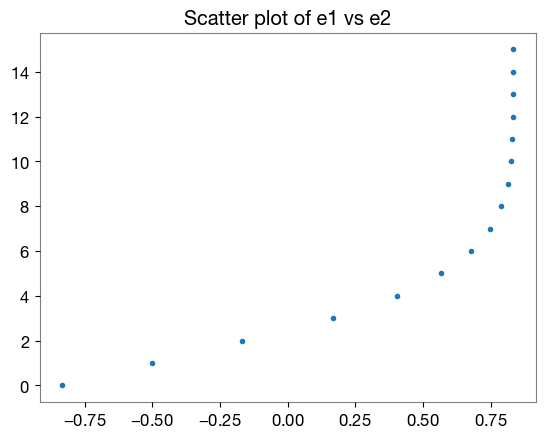

In [24]:
# plotting the points
import matplotlib.pyplot as plt
import numpy as np

e1 = np.array([
        -0.8329393234111079,
        -0.4998441654384119,
        -0.16674900746571597,
        0.1663461505069801,
        0.40381402362434116,
        0.5679930027853909,
        0.6774023015572149,
        0.7471107276270416,
        0.7891030311622808,
        0.8126435764838157,
        0.824637021070672,
        0.8299855965548962,
        0.8319424514061767,
        0.8324602957651374,
        0.8325341919445267,
        0.8325364664523719
    ])

# plt.plot(e1, np.zeros_like(e1), ".")
plt.plot(e1, np.arange(len(e1)), ".")
plt.title('Scatter plot of e1 vs e2')
plt.grid()
plt.show()

In [2]:
lensed_param = ler.sample_lens_parameters(10000)

zs = lensed_param["zs"]
zl = lensed_param["zl"]
sigma = lensed_param["sigma"]
q = lensed_param["q"]
phi = lensed_param["phi"]
gamma = lensed_param["gamma"]
gamma1 = lensed_param["gamma1"]
gamma2 = lensed_param["gamma2"]

sampling lens parameters with sample_all_routine_epl_shear_sl...


In [3]:
# interpolation
%timeit cs_interpolation = ler.cross_section(zs, zl, sigma, q, phi, gamma, gamma1, gamma2)

4.23 ms ± 60.3 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [4]:
ler.cross_section(zs[:10], zl[:10], sigma[:10], q[:10], phi[:10], gamma[:10], gamma1[:10], gamma2[:10])

array([2.32994023e-11, 9.39684748e-12, 1.17522025e-11,
       2.75452449e-11, 3.56906807e-11, 5.13906703e-13,
       1.55317746e-10, 3.04325245e-11, 6.84539183e-12,
       1.33839227e-11])

In [5]:
# lenstronomy
def cs_lenstronomy_fn():
    theta_E = ler.compute_einstein_radii(sigma, zl, zs)
    cs_lenstronomy = ler.cross_section_epl_shear_numerical_mp(
        theta_E,
        gamma,
        gamma1,
        gamma2,
        q,
        phi,
    )
    return cs_lenstronomy

%timeit cs_lenstronomy = cs_lenstronomy_fn()

583 ms ± 41.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [6]:
theta_E = ler.compute_einstein_radii(sigma[:10], zl[:10], zs[:10])
ler.cross_section_epl_shear_numerical_mp(
    theta_E[:10],
    gamma[:10],
    gamma1[:10],
    gamma2[:10],
    q[:10],
    phi[:10],
)

array([2.32880111e-11, 9.38446373e-12, 1.17514057e-11,
       2.79095985e-11, 3.56922224e-11, 5.15127114e-13,
       1.55322899e-10, 3.04331177e-11, 6.83736678e-12,
       1.34319491e-11])

In [7]:
Da_instance = ler.angular_diameter_distance.function
from ler.image_properties.cross_section_njit import make_cross_section_reinit
cross_section_epl_shear_njit = make_cross_section_reinit(Da_instance)

In [8]:
# lenstronomy with njitted cross-section
%timeit cs_lenstronomy_njit = cross_section_epl_shear_njit(zs, zl, sigma, q, phi, gamma, gamma1, gamma2)

212 ms ± 2.34 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [9]:
cross_section_epl_shear_njit(zs[:10], zl[:10], sigma[:10], q[:10], phi[:10], gamma[:10], gamma1[:10], gamma2[:10])

array([2.32880111e-11, 9.38446373e-12, 1.17514057e-11,
       2.79095900e-11, 3.56922224e-11, 5.15126865e-13,
       1.55322899e-10, 3.04331109e-11, 6.83736678e-12,
       1.34319491e-11])

sampling lens parameters with sample_all_routine_epl_shear_sl...
=== Runtime (s) over 1 repeats ===
Interpolation  : 0.0072 ± 0.0000
Lenstronomy    : 0.9914 ± 0.0000
Lenstronomy+JIT: 0.4232 ± 0.0000

=== Agreement vs Lenstronomy (reference) ===
Interpolation rel err: mean=2.510e-03, median=3.744e-04, p90=5.458e-03, p99=2.362e-02, max=1.245e+00
NJIT rel err: mean=1.079e-07, median=1.458e-15, p90=3.020e-07, p99=1.310e-06, max=6.898e-06


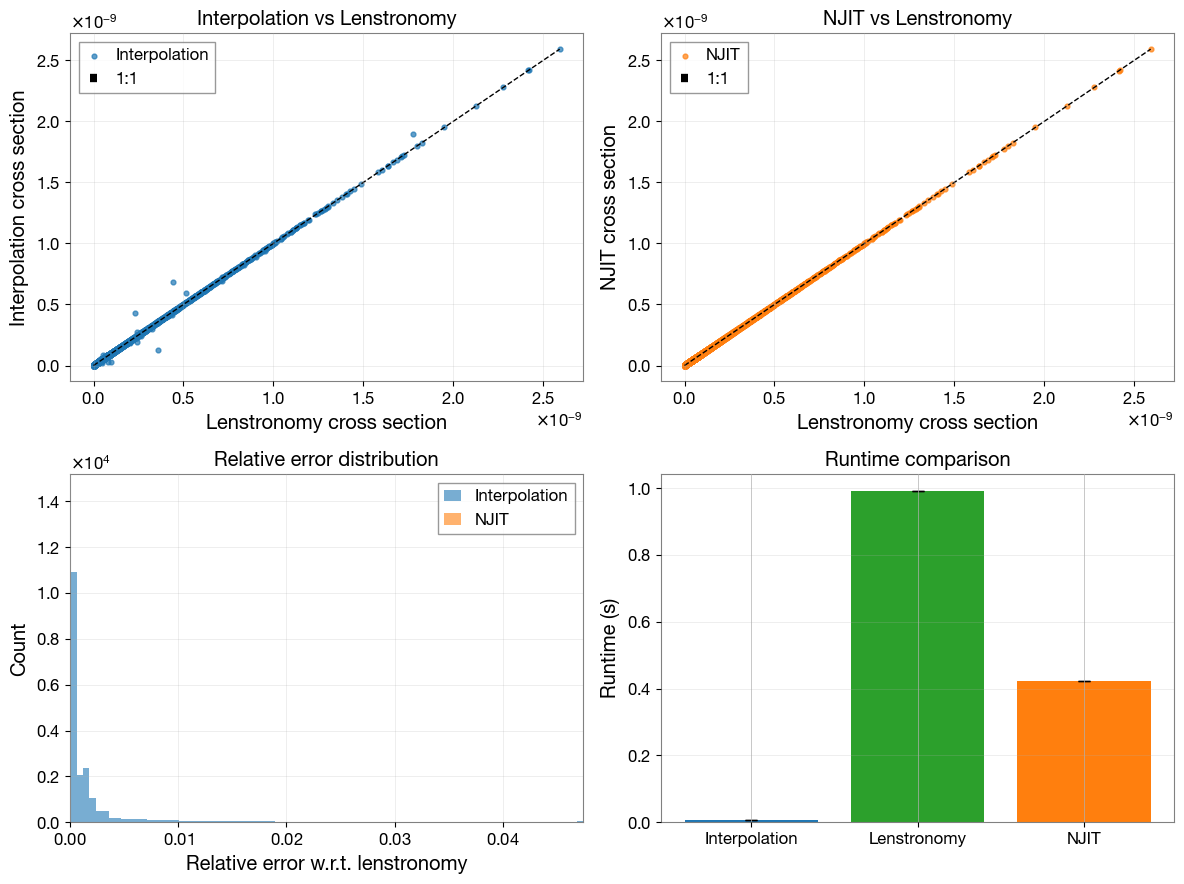

In [10]:
# Robust comparison: interpolation vs lenstronomy vs njitted lenstronomy
import time
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1) Build a robust sample
# -------------------------
rng = np.random.default_rng(1234)
n_samples = 20000

lensed_param_cmp = ler.sample_lens_parameters(n_samples)
zs_cmp = lensed_param_cmp["zs"]
zl_cmp = lensed_param_cmp["zl"]
sigma_cmp = lensed_param_cmp["sigma"]
q_cmp = lensed_param_cmp["q"]
phi_cmp = lensed_param_cmp["phi"]
gamma_cmp = lensed_param_cmp["gamma"]
gamma1_cmp = lensed_param_cmp["gamma1"]
gamma2_cmp = lensed_param_cmp["gamma2"]

# Deterministic shuffle (robust against ordering artifacts)
idx = rng.permutation(n_samples)
zs_cmp = zs_cmp[idx]
zl_cmp = zl_cmp[idx]
sigma_cmp = sigma_cmp[idx]
q_cmp = q_cmp[idx]
phi_cmp = phi_cmp[idx]
gamma_cmp = gamma_cmp[idx]
gamma1_cmp = gamma1_cmp[idx]
gamma2_cmp = gamma2_cmp[idx]

# -------------------------
# 2) Define calculators
# -------------------------
thetaE_cmp = ler.compute_einstein_radii(sigma_cmp, zl_cmp, zs_cmp)

def calc_interpolation():
    return np.asarray(
        ler.cross_section(
            zs_cmp, zl_cmp, sigma_cmp, q_cmp, phi_cmp, gamma_cmp, gamma1_cmp, gamma2_cmp
        )
    )

def calc_lenstronomy():
    return np.asarray(
        ler.cross_section_epl_shear_numerical_mp(
            thetaE_cmp, gamma_cmp, gamma1_cmp, gamma2_cmp, q_cmp, phi_cmp
        )
    )

def calc_njit():
    return np.asarray(
        cross_section_epl_shear_njit(
            zs_cmp, zl_cmp, sigma_cmp, q_cmp, phi_cmp, gamma_cmp, gamma1_cmp, gamma2_cmp
        )
    )

# Warm-up JIT and any internal caches
_ = calc_njit()
_ = calc_interpolation()
_ = calc_lenstronomy()

def timed(fn, repeat=1):
    times = []
    out = None
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        times.append(time.perf_counter() - t0)
    return out, np.mean(times), np.std(times)

# -------------------------
# 3) Run + benchmark
# -------------------------
cs_interp, t_interp_mean, t_interp_std = timed(calc_interpolation, repeat=1)
cs_lens, t_lens_mean, t_lens_std = timed(calc_lenstronomy, repeat=1)
cs_njit, t_njit_mean, t_njit_std = timed(calc_njit, repeat=1)

# -------------------------
# 4) Robust error metrics
# -------------------------
eps = 1e-20
safe_lens = np.maximum(np.abs(cs_lens), eps)

abs_err_interp = np.abs(cs_interp - cs_lens)
abs_err_njit = np.abs(cs_njit - cs_lens)

rel_err_interp = abs_err_interp / safe_lens
rel_err_njit = abs_err_njit / safe_lens

def summarize(name, arr):
    q50, q90, q99 = np.quantile(arr, [0.50, 0.90, 0.99])
    return f"{name}: mean={arr.mean():.3e}, median={q50:.3e}, p90={q90:.3e}, p99={q99:.3e}, max={arr.max():.3e}"

print("=== Runtime (s) over 1 repeats ===")
print(f"Interpolation  : {t_interp_mean:.4f} ± {t_interp_std:.4f}")
print(f"Lenstronomy    : {t_lens_mean:.4f} ± {t_lens_std:.4f}")
print(f"Lenstronomy+JIT: {t_njit_mean:.4f} ± {t_njit_std:.4f}")
print()
print("=== Agreement vs Lenstronomy (reference) ===")
print(summarize("Interpolation rel err", rel_err_interp))
print(summarize("NJIT rel err", rel_err_njit))

# -------------------------
# 5) Plot comparison
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (a) Scatter: interpolation vs lenstronomy
ax = axes[0, 0]
ax.scatter(cs_lens, cs_interp, s=12, alpha=0.7, label="Interpolation")
lims = [
    np.nanmin([cs_lens.min(), cs_interp.min()]),
    np.nanmax([cs_lens.max(), cs_interp.max()]),
]
ax.plot(lims, lims, "k--", lw=1, label="1:1")
ax.set_xlabel("Lenstronomy cross section")
ax.set_ylabel("Interpolation cross section")
ax.set_title("Interpolation vs Lenstronomy")
ax.legend()
ax.grid(alpha=0.3)

# ax = axes[0, 0]
# ax.scatter(cs_njit, cs_interp, s=12, alpha=0.7, label="Interpolation")
# lims = [
#     np.nanmin([cs_njit.min(), cs_interp.min()]),
#     np.nanmax([cs_njit.max(), cs_interp.max()]),
# ]
# ax.plot(lims, lims, "k--", lw=1, label="1:1")
# ax.set_xlabel("NJIT cross section")
# ax.set_ylabel("Interpolation cross section")
# ax.set_title("Interpolation vs NJIT")
# ax.legend()
# ax.grid(alpha=0.3)


# (b) Scatter: njit vs lenstronomy
ax = axes[0, 1]
ax.scatter(cs_lens, cs_njit, s=12, alpha=0.7, color="tab:orange", label="NJIT")
lims = [
    np.nanmin([cs_lens.min(), cs_njit.min()]),
    np.nanmax([cs_lens.max(), cs_njit.max()]),
]
ax.plot(lims, lims, "k--", lw=1, label="1:1")
ax.set_xlabel("Lenstronomy cross section")
ax.set_ylabel("NJIT cross section")
ax.set_title("NJIT vs Lenstronomy")
ax.legend()
ax.grid(alpha=0.3)

# (c) Relative error distributions (robust view)
ax = axes[1, 0]
valid_hist = (
    np.isfinite(rel_err_interp)
    & np.isfinite(rel_err_njit)
    & np.isfinite(cs_lens)
    & (np.abs(cs_lens) > 1e-20)
)

rel_i = rel_err_interp[valid_hist]
rel_n = rel_err_njit[valid_hist]

if rel_i.size > 0:
    hi = np.quantile(np.concatenate([rel_i, rel_n]), 0.999)
    hi = max(hi, 1e-18)
    ax.hist(np.clip(rel_i, 0, hi), bins=80, alpha=0.6, label="Interpolation", density=False)
    ax.hist(np.clip(rel_n, 0, hi), bins=80, alpha=0.6, label="NJIT", density=False)
    ax.set_xlim(0, hi)
else:
    ax.text(0.5, 0.5, "No finite relative-error samples", ha="center", va="center", transform=ax.transAxes)

ax.set_xlabel("Relative error w.r.t. lenstronomy")
ax.set_ylabel("Count")
ax.set_title("Relative error distribution")
ax.legend()
ax.grid(alpha=0.3)

# (d) Runtime comparison
ax = axes[1, 1]
labels = ["Interpolation", "Lenstronomy", "NJIT"]
means = [t_interp_mean, t_lens_mean, t_njit_mean]
stds = [t_interp_std, t_lens_std, t_njit_std]
ax.bar(labels, means, yerr=stds, capsize=4, color=["tab:blue", "tab:green", "tab:orange"])
ax.set_ylabel("Runtime (s)")
ax.set_title("Runtime comparison")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
# Hermite Interpolation rel err: mean=2.633e-03, median=1.919e-04, p90=9.259e-03, p99=2.085e-02, max=1.950e-01
# Cubic Interpolation rel err: mean=4.340e-03, median=1.844e-03, p90=1.067e-02, p99=2.895e-02, max=6.571e-01

# lenstronomy Interpolation rel err: mean=1.752e-03, median=3.773e-05, p90=4.857e-03, p99=1.491e-02, max=1.104e+00
# njit Interpolation rel err: mean=3.264e-03, median=6.274e-05, p90=6.449e-03, p99=2.530e-02, max=1.125e+00

# njit (e1,e2 linear) Interpolation rel err: mean=2.100e-03, median=2.539e-05, p90=3.194e-03, p99=2.405e-02, max=1.297e+00

In [11]:
# calculate absolute error and percent error
abs_err = np.abs(cs_interp - cs_lens)
percent_err = abs_err / np.abs(cs_lens) * 100

print(f"Mean absolute error: {abs_err.mean():.3e}")
print(f"Mean percent error: {percent_err.mean():.3f}%")
print(f"Max absolute error: {abs_err.max():.3e}")
print(f"Max percent error: {percent_err.max():.3f}%")


Mean absolute error: 1.492e-13
Mean percent error: 0.251%
Max absolute error: 2.408e-10
Max percent error: 124.542%


In [12]:
# inspect parameters of high error cases
high_err_idx = np.where(rel_err_interp > 1.0)[0]
from ler.image_properties.cross_section_njit import phi_q2_ellipticity
e1_cmp, e2_cmp = phi_q2_ellipticity(phi_cmp, q_cmp)
print("High relative error cases (interp vs lenstronomy):")
for idx in high_err_idx[:10]:  # show up to 10 cases
    print(f"Index {idx}:")
    print(f"  theta_E={thetaE_cmp[idx]}, e1={e1_cmp[idx]:.3f}, e2={e2_cmp[idx]:.3f}, gamma={gamma_cmp[idx]:.3f}, gamma1={gamma1_cmp[idx]:.3f}, gamma2={gamma2_cmp[idx]:.3f}")
    print(f"  Cross section (lenstronomy) = {cs_lens[idx]:.3e}")
    print(f"  Cross section (interp)     = {cs_interp[idx]:.3e}")
    print(f"  Relative error            = {rel_err_interp[idx]:.3e}")

High relative error cases (interp vs lenstronomy):
Index 5552:
  theta_E=5.095132763151471e-07, e1=0.214, e2=-0.012, gamma=2.536, gamma1=0.069, gamma2=-0.025
  Cross section (lenstronomy) = 4.196e-12
  Cross section (interp)     = 9.422e-12
  Relative error            = 1.245e+00


sampling lens parameters with sample_all_routine_epl_shear_sl...
=== Runtime (s) over 5 repeats ===
Interpolation  : 0.0115 ± 0.0002
Lenstronomy    : 0.5359 ± 0.0030
Lenstronomy+JIT: 0.2330 ± 0.0038

=== Agreement vs Lenstronomy (reference) ===
Interpolation rel err: mean=3.176e-03, median=6.324e-04, p90=7.028e-03, p99=2.441e-02, max=1.363e+00
NJIT rel err: mean=1.140e-07, median=1.480e-15, p90=3.175e-07, p99=1.479e-06, max=5.033e-06


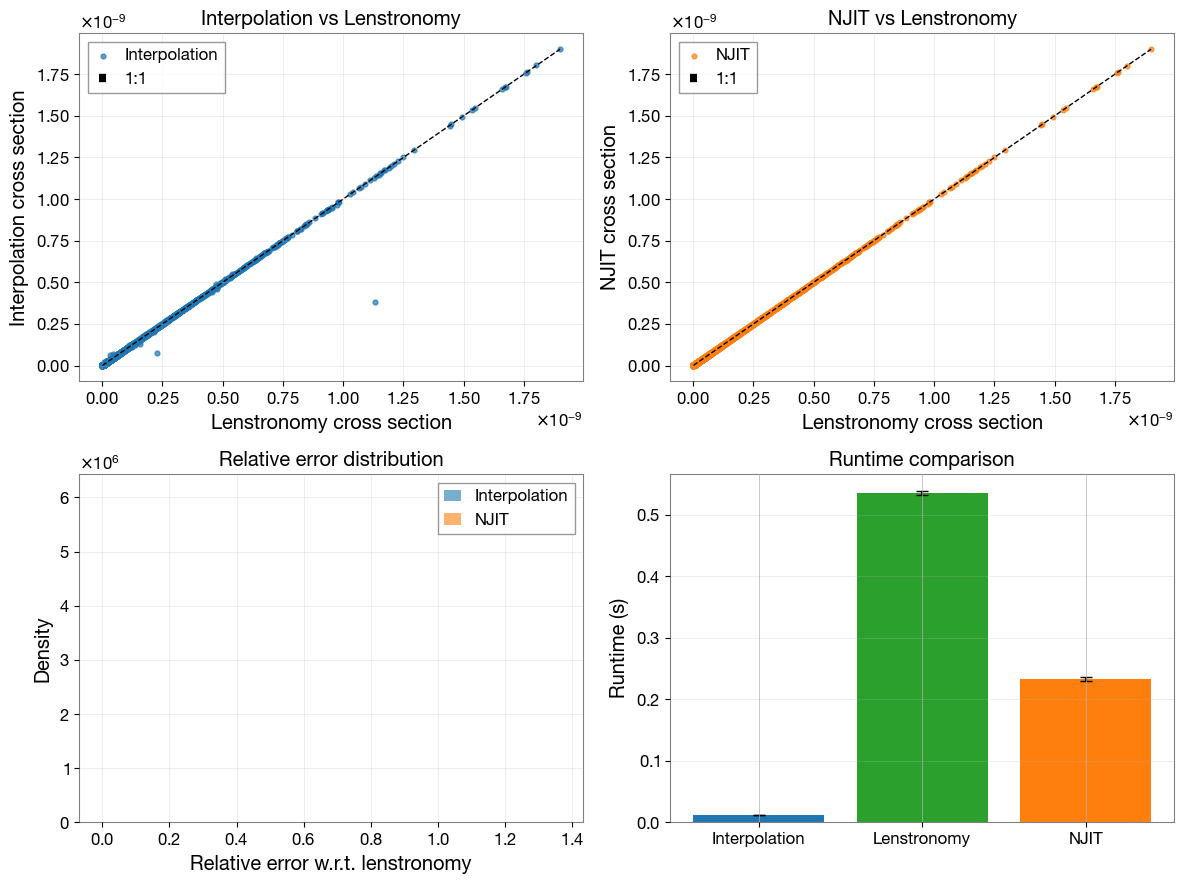

In [7]:
# Robust comparison: interpolation vs lenstronomy vs njitted lenstronomy
import time
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1) Build a robust sample
# -------------------------
rng = np.random.default_rng(1234)
n_samples = 10000

lensed_param_cmp = ler.sample_lens_parameters(n_samples)
zs_cmp = lensed_param_cmp["zs"]
zl_cmp = lensed_param_cmp["zl"]
sigma_cmp = lensed_param_cmp["sigma"]
q_cmp = lensed_param_cmp["q"]
phi_cmp = lensed_param_cmp["phi"]
gamma_cmp = lensed_param_cmp["gamma"]
gamma1_cmp = lensed_param_cmp["gamma1"]
gamma2_cmp = lensed_param_cmp["gamma2"]

# Deterministic shuffle (robust against ordering artifacts)
idx = rng.permutation(n_samples)
zs_cmp = zs_cmp[idx]
zl_cmp = zl_cmp[idx]
sigma_cmp = sigma_cmp[idx]
q_cmp = q_cmp[idx]
phi_cmp = phi_cmp[idx]
gamma_cmp = gamma_cmp[idx]
gamma1_cmp = gamma1_cmp[idx]
gamma2_cmp = gamma2_cmp[idx]

# -------------------------
# 2) Define calculators
# -------------------------
thetaE_cmp = ler.compute_einstein_radii(sigma_cmp, zl_cmp, zs_cmp)

def calc_interpolation():
    return np.asarray(
        ler.cross_section(
            zs_cmp, zl_cmp, sigma_cmp, q_cmp, phi_cmp, gamma_cmp, gamma1_cmp, gamma2_cmp
        )
    )

def calc_lenstronomy():
    return np.asarray(
        ler.cross_section_epl_shear_numerical_mp(
            thetaE_cmp, gamma_cmp, gamma1_cmp, gamma2_cmp, q_cmp, phi_cmp
        )
    )

def calc_njit():
    return np.asarray(
        cross_section_epl_shear_njit(
            zs_cmp, zl_cmp, sigma_cmp, q_cmp, phi_cmp, gamma_cmp, gamma1_cmp, gamma2_cmp
        )
    )

# Warm-up JIT and any internal caches
_ = calc_njit()
_ = calc_interpolation()
_ = calc_lenstronomy()

def timed(fn, repeat=3):
    times = []
    out = None
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        times.append(time.perf_counter() - t0)
    return out, np.mean(times), np.std(times)

# -------------------------
# 3) Run + benchmark
# -------------------------
cs_interp, t_interp_mean, t_interp_std = timed(calc_interpolation, repeat=5)
cs_lens, t_lens_mean, t_lens_std = timed(calc_lenstronomy, repeat=5)
cs_njit, t_njit_mean, t_njit_std = timed(calc_njit, repeat=5)

# -------------------------
# 4) Robust error metrics
# -------------------------
eps = 1e-20
safe_lens = np.maximum(np.abs(cs_lens), eps)

abs_err_interp = np.abs(cs_interp - cs_lens)
abs_err_njit = np.abs(cs_njit - cs_lens)

rel_err_interp = abs_err_interp / safe_lens
rel_err_njit = abs_err_njit / safe_lens

def summarize(name, arr):
    q50, q90, q99 = np.quantile(arr, [0.50, 0.90, 0.99])
    return f"{name}: mean={arr.mean():.3e}, median={q50:.3e}, p90={q90:.3e}, p99={q99:.3e}, max={arr.max():.3e}"

print("=== Runtime (s) over 5 repeats ===")
print(f"Interpolation  : {t_interp_mean:.4f} ± {t_interp_std:.4f}")
print(f"Lenstronomy    : {t_lens_mean:.4f} ± {t_lens_std:.4f}")
print(f"Lenstronomy+JIT: {t_njit_mean:.4f} ± {t_njit_std:.4f}")
print()
print("=== Agreement vs Lenstronomy (reference) ===")
print(summarize("Interpolation rel err", rel_err_interp))
print(summarize("NJIT rel err", rel_err_njit))

# -------------------------
# 5) Plot comparison
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (a) Scatter: interpolation vs lenstronomy
ax = axes[0, 0]
ax.scatter(cs_lens, cs_interp, s=12, alpha=0.7, label="Interpolation")
lims = [
    np.nanmin([cs_lens.min(), cs_interp.min()]),
    np.nanmax([cs_lens.max(), cs_interp.max()]),
]
ax.plot(lims, lims, "k--", lw=1, label="1:1")
ax.set_xlabel("Lenstronomy cross section")
ax.set_ylabel("Interpolation cross section")
ax.set_title("Interpolation vs Lenstronomy")
ax.legend()
ax.grid(alpha=0.3)

# (b) Scatter: njit vs lenstronomy
ax = axes[0, 1]
ax.scatter(cs_lens, cs_njit, s=12, alpha=0.7, color="tab:orange", label="NJIT")
lims = [
    np.nanmin([cs_lens.min(), cs_njit.min()]),
    np.nanmax([cs_lens.max(), cs_njit.max()]),
]
ax.plot(lims, lims, "k--", lw=1, label="1:1")
ax.set_xlabel("Lenstronomy cross section")
ax.set_ylabel("NJIT cross section")
ax.set_title("NJIT vs Lenstronomy")
ax.legend()
ax.grid(alpha=0.3)

# (c) Relative error distributions
ax = axes[1, 0]
ax.hist(rel_err_interp, bins=40, alpha=0.6, label="Interpolation", density=True)
ax.hist(rel_err_njit, bins=40, alpha=0.6, label="NJIT", density=True)
ax.set_xlabel("Relative error w.r.t. lenstronomy")
ax.set_ylabel("Density")
ax.set_title("Relative error distribution")
ax.legend()
ax.grid(alpha=0.3)

# (d) Runtime comparison
ax = axes[1, 1]
labels = ["Interpolation", "Lenstronomy", "NJIT"]
means = [t_interp_mean, t_lens_mean, t_njit_mean]
stds = [t_interp_std, t_lens_std, t_njit_std]
ax.bar(labels, means, yerr=stds, capsize=4, color=["tab:blue", "tab:green", "tab:orange"])
ax.set_ylabel("Runtime (s)")
ax.set_title("Runtime comparison")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Total samples: 20000
Top 5.0% threshold (relative error): 6.662e-02
Global median / p90 / p99 / max: 1.956e-03 / 5.321e-02 / 7.433e-02 / 1.473e+00

Parameter ranges in high-error subset:
e1           all[p05,p50,p95]=(-0.284, 0.00103, 0.287)  high_err[p05,p50,p95]=(-0.256, 0.00476, 0.247)
e2           all[p05,p50,p95]=(-0.278, 0.000243, 0.282)  high_err[p05,p50,p95]=(-0.274, -0.0127, 0.245)
gamma        all[p05,p50,p95]=(1.89, 2.1, 2.32)  high_err[p05,p50,p95]=(1.82, 1.96, 2.36)
gamma1       all[p05,p50,p95]=(-0.0829, 2.85e-05, 0.0826)  high_err[p05,p50,p95]=(-0.0829, 0.0015, 0.075)
gamma2       all[p05,p50,p95]=(-0.0817, -0.00021, 0.0841)  high_err[p05,p50,p95]=(-0.087, -0.00346, 0.0849)
|shear|      all[p05,p50,p95]=(0.0161, 0.0588, 0.123)  high_err[p05,p50,p95]=(0.0161, 0.0582, 0.126)
theta_E      all[p05,p50,p95]=(6.43e-07, 2.28e-06, 7.14e-06)  high_err[p05,p50,p95]=(6.02e-07, 2.32e-06, 6.71e-06)


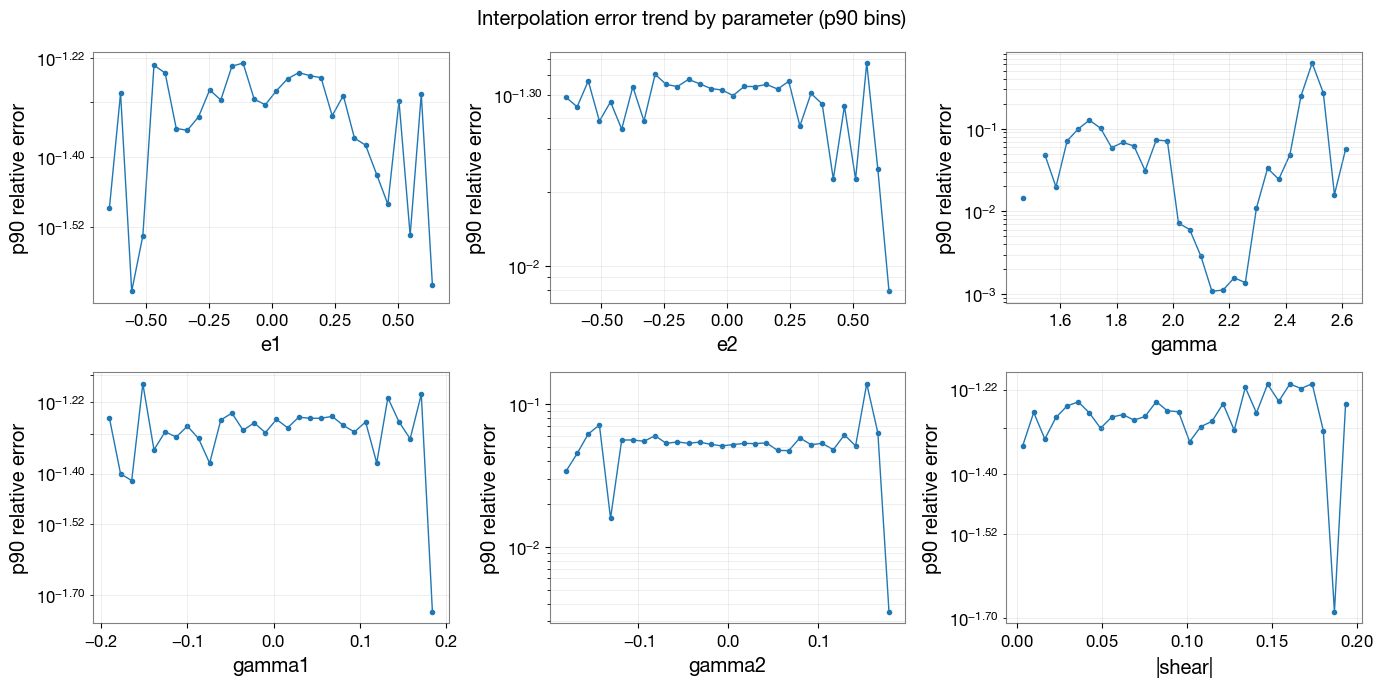

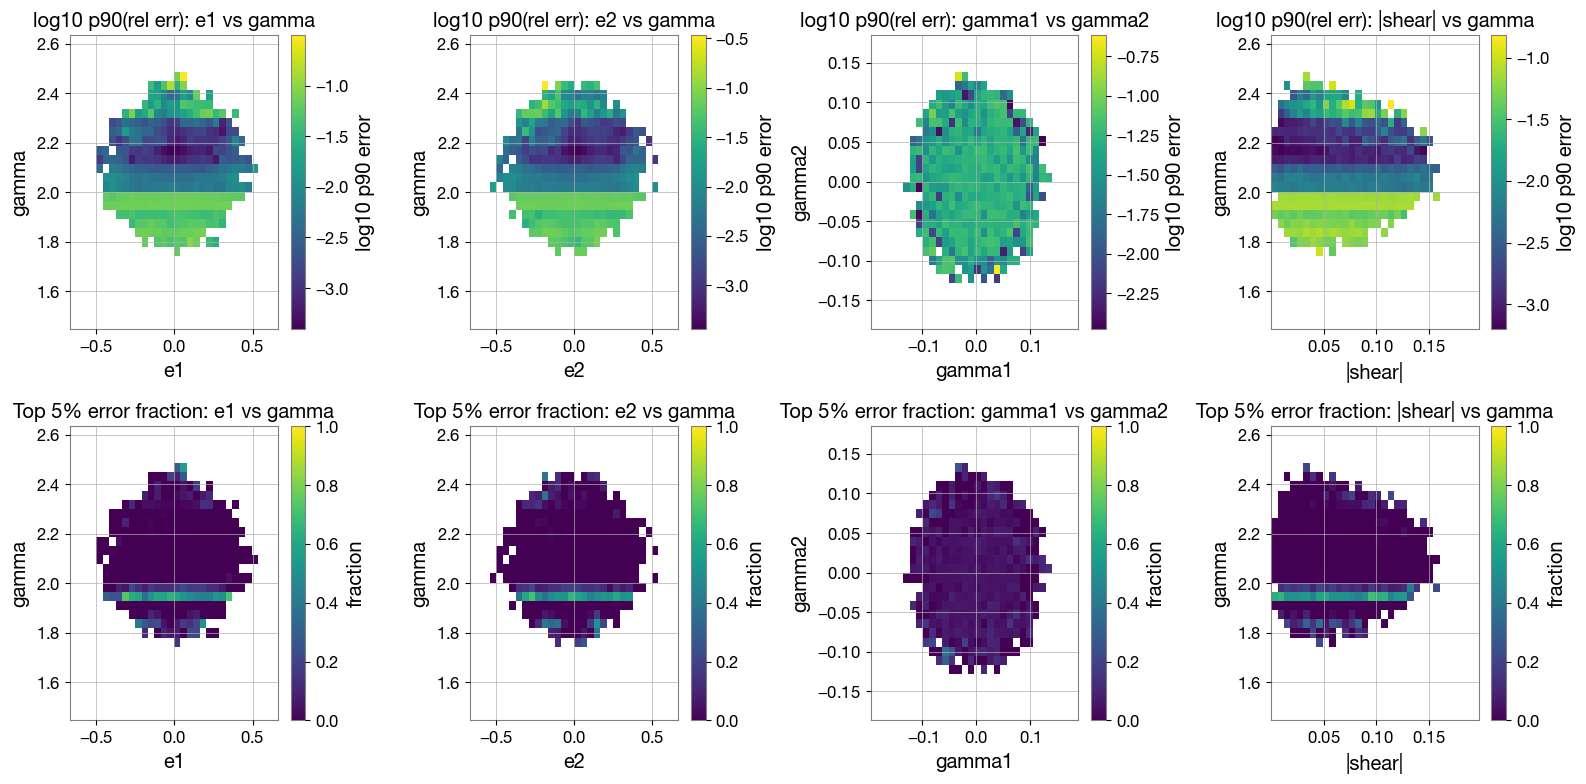

In [26]:
# Where does interpolation error increase? (e1, e2, gamma, gamma1, gamma2 focused)
import numpy as np
import matplotlib.pyplot as plt

# Relative error against lenstronomy reference from Cell 7
rel = np.asarray(rel_err_interp)
log_rel = np.log10(np.maximum(rel, 1e-18))

# Build interpolation-space parameters explicitly
e1_cmp = (1.0 - q_cmp) / (1.0 + q_cmp) * np.cos(2.0 * phi_cmp)
e2_cmp = (1.0 - q_cmp) / (1.0 + q_cmp) * np.sin(2.0 * phi_cmp)
shear_mag = np.sqrt(gamma1_cmp**2 + gamma2_cmp**2)

# Top-error region (tail selection)
q_hi = 0.95
thr = np.quantile(rel, q_hi)
hi = rel >= thr

print(f"Total samples: {rel.size}")
print(f"Top {(1-q_hi)*100:.1f}% threshold (relative error): {thr:.3e}")
print(
    f"Global median / p90 / p99 / max: "
    f"{np.quantile(rel,0.5):.3e} / {np.quantile(rel,0.9):.3e} / "
    f"{np.quantile(rel,0.99):.3e} / {rel.max():.3e}"
)

def summarize_param(name, x):
    q_all = np.quantile(x, [0.05, 0.5, 0.95])
    q_bad = np.quantile(x[hi], [0.05, 0.5, 0.95])
    print(
        f"{name:12s} all[p05,p50,p95]=({q_all[0]:.3g}, {q_all[1]:.3g}, {q_all[2]:.3g})  "
        f"high_err[p05,p50,p95]=({q_bad[0]:.3g}, {q_bad[1]:.3g}, {q_bad[2]:.3g})"
    )

print("\nParameter ranges in high-error subset:")
summarize_param("e1", e1_cmp)
summarize_param("e2", e2_cmp)
summarize_param("gamma", gamma_cmp)
summarize_param("gamma1", gamma1_cmp)
summarize_param("gamma2", gamma2_cmp)
summarize_param("|shear|", shear_mag)
summarize_param("theta_E", thetaE_cmp)

# ----- 1D binned p90(error) vs each target parameter -----
def binned_p90(x, y, nbins=30):
    edges = np.linspace(np.min(x), np.max(x), nbins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    out = np.full(nbins, np.nan)
    for i in range(nbins):
        if i < nbins - 1:
            m = (x >= edges[i]) & (x < edges[i + 1])
        else:
            m = (x >= edges[i]) & (x <= edges[i + 1])
        if np.count_nonzero(m) > 0:
            out[i] = np.quantile(y[m], 0.90)
    return centers, out

params = [
    (e1_cmp, "e1"),
    (e2_cmp, "e2"),
    (gamma_cmp, "gamma"),
    (gamma1_cmp, "gamma1"),
    (gamma2_cmp, "gamma2"),
    (shear_mag, "|shear|"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (x, name) in zip(axes.ravel(), params):
    c, v = binned_p90(x, rel, nbins=30)
    ax.plot(c, v, marker="o", ms=3, lw=1)
    ax.set_yscale("log")
    ax.set_xlabel(name)
    ax.set_ylabel("p90 relative error")
    ax.grid(alpha=0.3, which="both")

plt.suptitle("Interpolation error trend by parameter (p90 bins)")
plt.tight_layout()
plt.show()

# ----- 2D maps: p90 error + top-tail fraction -----
def binned_stat_2d(x, y, z, nx=36, ny=36, qstat=0.90):
    xedges = np.linspace(np.min(x), np.max(x), nx + 1)
    yedges = np.linspace(np.min(y), np.max(y), ny + 1)
    out = np.full((ny, nx), np.nan)
    for i in range(nx):
        if i < nx - 1:
            mx = (x >= xedges[i]) & (x < xedges[i + 1])
        else:
            mx = (x >= xedges[i]) & (x <= xedges[i + 1])
        for j in range(ny):
            if j < ny - 1:
                my = (y >= yedges[j]) & (y < yedges[j + 1])
            else:
                my = (y >= yedges[j]) & (y <= yedges[j + 1])
            m = mx & my
            if np.count_nonzero(m) >= 8:
                out[j, i] = np.quantile(z[m], qstat)
    return out, xedges, yedges

def high_error_fraction_2d(x, y, mask_hi, nx=36, ny=36):
    xedges = np.linspace(np.min(x), np.max(x), nx + 1)
    yedges = np.linspace(np.min(y), np.max(y), ny + 1)
    out = np.full((ny, nx), np.nan)
    for i in range(nx):
        if i < nx - 1:
            mx = (x >= xedges[i]) & (x < xedges[i + 1])
        else:
            mx = (x >= xedges[i]) & (x <= xedges[i + 1])
        for j in range(ny):
            if j < ny - 1:
                my = (y >= yedges[j]) & (y < yedges[j + 1])
            else:
                my = (y >= yedges[j]) & (y <= yedges[j + 1])
            m = mx & my
            n = np.count_nonzero(m)
            if n >= 8:
                out[j, i] = np.count_nonzero(mask_hi[m]) / n
    return out, xedges, yedges

pairs = [
    (e1_cmp, gamma_cmp, "e1", "gamma"),
    (e2_cmp, gamma_cmp, "e2", "gamma"),
    (gamma1_cmp, gamma2_cmp, "gamma1", "gamma2"),
    (shear_mag, gamma_cmp, "|shear|", "gamma"),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, (x, y, xn, yn) in enumerate(pairs):
    p90map, xe, ye = binned_stat_2d(x, y, rel, nx=32, ny=32, qstat=0.90)
    fracmap, xe2, ye2 = high_error_fraction_2d(x, y, hi, nx=32, ny=32)

    im = axes[0, col].pcolormesh(
        xe, ye, np.log10(np.maximum(p90map, 1e-18)), shading="auto"
    )
    axes[0, col].set_xlabel(xn)
    axes[0, col].set_ylabel(yn)
    axes[0, col].set_title(f"log10 p90(rel err): {xn} vs {yn}")
    fig.colorbar(im, ax=axes[0, col], label="log10 p90 error")

    im2 = axes[1, col].pcolormesh(xe2, ye2, fracmap, shading="auto", vmin=0, vmax=1)
    axes[1, col].set_xlabel(xn)
    axes[1, col].set_ylabel(yn)
    axes[1, col].set_title(f"Top 5% error fraction: {xn} vs {yn}")
    fig.colorbar(im2, ax=axes[1, col], label="fraction")

plt.tight_layout()
plt.show()

In [14]:
lensed_param = ler.lensed_cbc_statistics(resume=False)
_, lensed_param_det = ler.lensed_rate()

lensed params will be stored in ./ler_data/lensed_param.json
removing ./ler_data/lensed_param.json if it exists
Batch no. 1
sampling lensed params...
sampling lens parameters with sample_all_routine_epl_shear_sl...
solving lens equations...


100%|███████████████████████████████████████████████████████| 50000/50000 [00:07<00:00, 6643.26it/s]


calculating pdet...
Batch no. 2
sampling lensed params...
sampling lens parameters with sample_all_routine_epl_shear_sl...
solving lens equations...


100%|███████████████████████████████████████████████████████| 50000/50000 [00:07<00:00, 6677.39it/s]


calculating pdet...
saving all lensed parameters in ./ler_data/lensed_param.json 
Getting lensed_param from json file ./ler_data/lensed_param.json...
total lensed rate (yr^-1): 0.11081729003726844
number of simulated lensed detectable events: 98
number of simulated all lensed events: 100000
storing detectable params in ./ler_data/lensed_param_detectable.json
